## The data
- Handwritten numbers preprocessed for machine learning 
- Our goal is to create a cassiffier that can recognize the digits

In [3]:
import pandas as pd
from sklearn.datasets import load_digits

In [4]:
digits = load_digits()

In [5]:
digits.images

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

<Figure size 640x480 with 0 Axes>

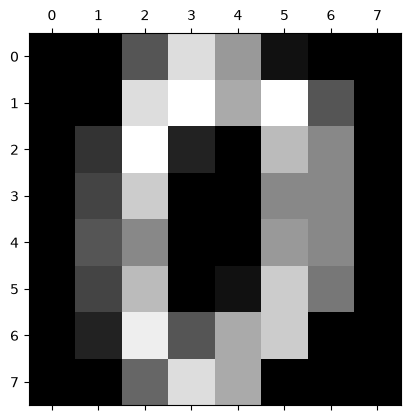

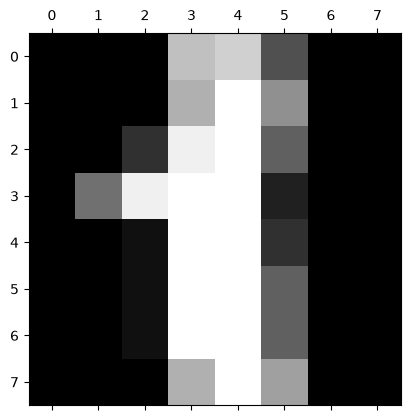

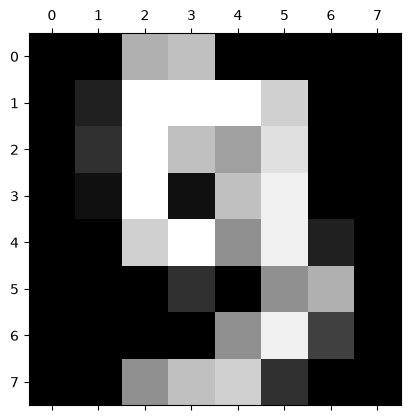

In [6]:
# Look at the images

import matplotlib.pyplot as plt

plt.gray()
plt.matshow(digits.images[0])
plt.matshow(digits.images[1])
plt.matshow(digits.images[9])

## Workflow
- X & y 
- train test split 
- Train evauate the best models 
- Hyper parameter tunning 
- Predict on test data 

In [7]:
# Train test split 
X = digits.data

y = digits.target

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)

In [9]:
# Train ad evaluate diff models 

#importing all our models to compare them
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#import tools 
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import GridSearchCV

In [10]:
classifiers =[
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    SVC(),
    KNeighborsClassifier()
]

scaler = StandardScaler()

In [ ]:
classifiers =[
    LogisticRegression(),
    DecisionTreeClassifier(),
    RandomForestClassifier(),
    SVC(),
    KNeighborsClassifier()
]

scaler = StandardScaler()

for i in classifiers:
    pipe = make_pipeline(scaler,i)
    grid = GridSearchCV(estimator=pipe, param_grid={}, cv = 5, scoring="accuracy")
    grid.fit(X_train,y_train)

    print(f"Train score for {i}: {grid.best_score_}\n")
    

Train score for LogisticRegression(): 0.956929643398045

Train score for DecisionTreeClassifier(): 0.8307090733856534

Train score for RandomForestClassifier(): 0.9673385653311304

Train score for SVC(): 0.9725292578824177

Train score for KNeighborsClassifier(): 0.9688228004956629



In [12]:
param_grid_logreg = {
    "logisticregression__C": [0.1, 1, 1.5, 2]
}

classifier = LogisticRegression(max_iter=1000,random_state=42)

pipe = make_pipeline(scaler,classifier)

grid_logreg = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid_logreg,
    cv = 5,
    scoring = "accuracy"
)

grid_logreg.fit(X_train, y_train)

print(f"Best socre: {grid_logreg.best_score_}")
print(f"Best param: {grid_logreg.best_params_}")


Best socre: 0.956929643398045
Best param: {'logisticregression__C': 1}


In [16]:
#Random Forest
param_grid_rf = {
    "randomforestclassifier__min_samples_leaf": [1, 2, 4],
    "randomforestclassifier__max_depth": [10, 50, None],
    "randomforestclassifier__n_estimators": [100, 200, 500]
}

classifier = RandomForestClassifier(n_jobs = -1)

pipe = make_pipeline(scaler, classifier)

grid_rf = GridSearchCV(
    estimator = pipe,
    param_grid= param_grid_rf,
    cv = 5,
    scoring= "accuracy"
)

grid_rf.fit(X_train, y_train)

print(f"Best socre: {grid_rf.best_score_}")
print(f"Best param: {grid_rf.best_params_}")

Best socre: 0.9732782596723117
Best param: {'randomforestclassifier__max_depth': 50, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}


In [19]:
# SVC 
para_grid_svc = {
    "svc__C": [0.1, 1, 10, 100, 1000],
    "svc__gamma": [1, 0.1, 0.01, 0.001, 0.0001]
}
classifier = SVC()
pipe = make_pipeline(scaler,classifier)

grid_svc = GridSearchCV(
    estimator=pipe,
    param_grid=para_grid_svc,
    cv= 5,
    scoring= "accuracy"
)

grid_svc.fit(X_train,y_train)

print(f"Best socre: {grid_svc.best_score_}")
print(f"Best param: {grid_svc.best_params_}")

Best socre: 0.979215200330442
Best param: {'svc__C': 10, 'svc__gamma': 0.01}


In [28]:
#KNN

para_grid_knc = {
    "kneighborsclassifier__n_neighbors": [3, 5, 11],
    "kneighborsclassifier__metric": ["minkowski","euclidean"]
}

classifier = KNeighborsClassifier(n_jobs = -1)
pipe = make_pipeline(scaler,classifier)

grid_knc = GridSearchCV(
    estimator=pipe,
    param_grid=para_grid_knc,
    cv= 5,
    scoring= "accuracy"
)

grid_knc.fit(X_train,y_train)

print(f"Best socre: {grid_knc.best_score_}")
print(f"Best param: {grid_knc.best_params_}")

Best socre: 0.9732727523062096
Best param: {'kneighborsclassifier__metric': 'minkowski', 'kneighborsclassifier__n_neighbors': 3}


Accuracy for logreg: 0.9985152190051967
With parameters {'logisticregression__C': 1}



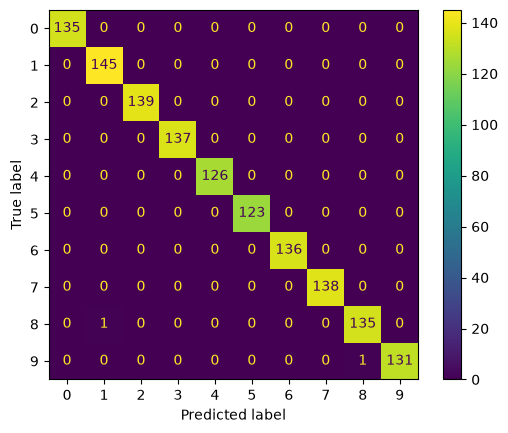

Accuracy for randomforest: 1.0
With parameters {'randomforestclassifier__max_depth': 50, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}



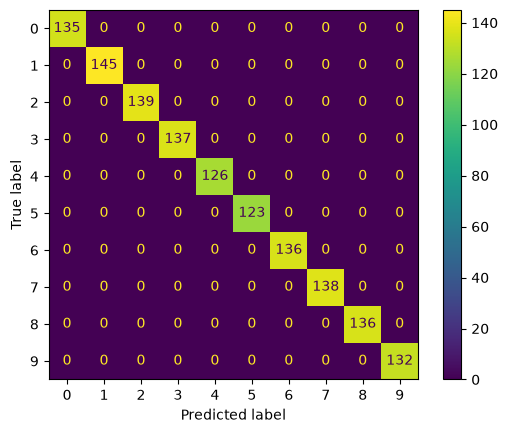

Accuracy for svc: 1.0
With parameters {'svc__C': 10, 'svc__gamma': 0.01}



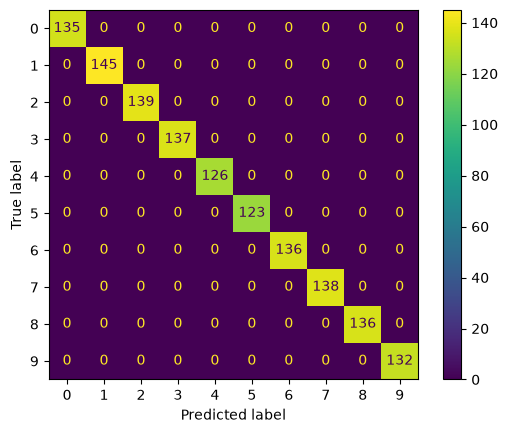

Accuracy for kneighbors: 0.9866369710467706
With parameters {'kneighborsclassifier__metric': 'minkowski', 'kneighborsclassifier__n_neighbors': 3}



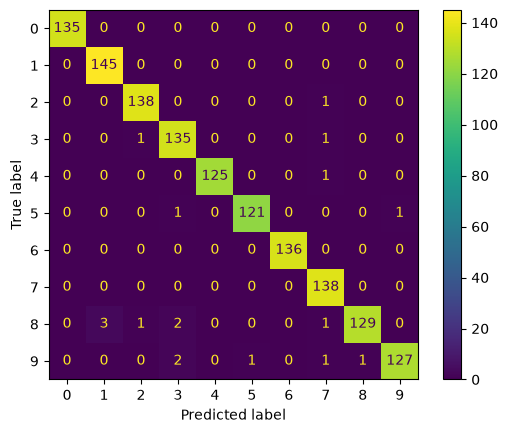

In [29]:
#Final evauation on training data
# sent this to students
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
trained_models = {
    'logreg': grid_logreg
    ,'randomforest': grid_rf
    ,'svc': grid_svc
    ,'kneighbors': grid_knc
}

for name, model in trained_models.items():
    y_pred = model.predict(X_train)
    score = model.score(X_train, y_train)
    accuracy = accuracy_score(y_train, y_pred)
    params = model.best_params_

    print(f"Accuracy for {name}: {accuracy}")
    print(f"With parameters {params}\n")
    ConfusionMatrixDisplay.from_estimator(model, X_train, y_train)
    plt.show()

Score for logreg: 0.9711111111111111
Accuracy for logreg: 1.0
With parameters {'logisticregression__C': 1}



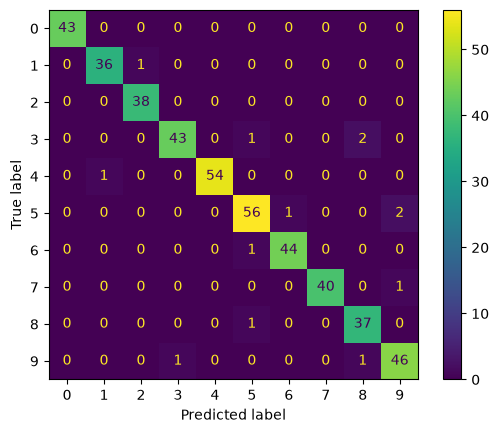

Score for randomforest: 0.9777777777777777
Accuracy for randomforest: 1.0
With parameters {'randomforestclassifier__max_depth': 50, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}



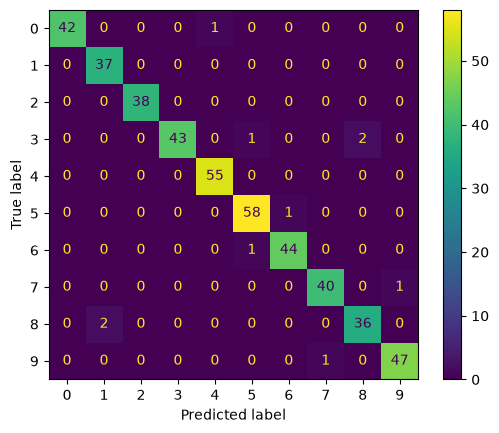

Score for svc: 0.9822222222222222
Accuracy for svc: 1.0
With parameters {'svc__C': 10, 'svc__gamma': 0.01}



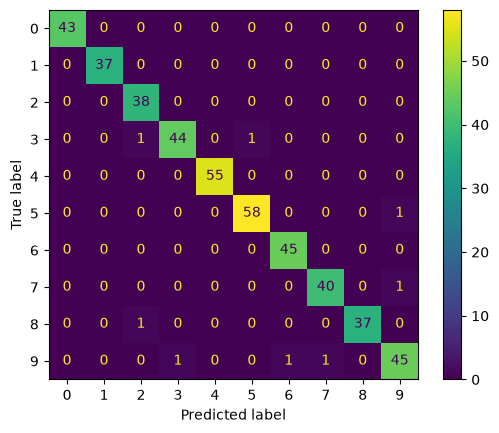

Score for kneighbors: 0.9666666666666667
Accuracy for kneighbors: 1.0
With parameters {'kneighborsclassifier__metric': 'minkowski', 'kneighborsclassifier__n_neighbors': 3}



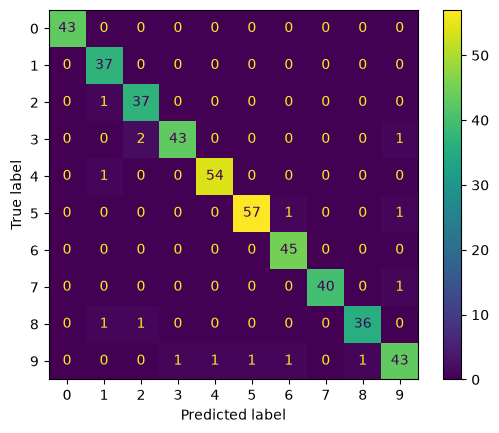

In [31]:
## Final evaluation on test data

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
trained_models = {
    'logreg': grid_logreg
    ,'randomforest': grid_rf
    ,'svc': grid_svc
    ,'kneighbors': grid_knc
}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    score = model.score(X_test, y_test)
    accuracy = accuracy_score(y_test, y_test)
    params = model.best_params_

    print(f"Score for {name}: {score}")
    print(f"Accuracy for {name}: {accuracy}")
    print(f"With parameters {params}\n")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()